In [2]:
pip install git+https://github.com/laxmimerit/preprocess_kgptalkie_old.git

  Cloning https://github.com/laxmimerit/preprocess_kgptalkie_old.git to /tmp/pip-req-build-u5tjgmju
  Running command git clone --filter=blob:none --quiet https://github.com/laxmimerit/preprocess_kgptalkie_old.git /tmp/pip-req-build-u5tjgmju
  Resolved https://github.com/laxmimerit/preprocess_kgptalkie_old.git to commit e5b1f0710cb1ea5ebbc73d30abe8d45a07cbb399
  Preparing metadata (setup.py) ... done


In [3]:
#!pip install spacy==3.7.6
#!python -m spacy download en_core_web_sm
#!pip install nltk==3.9.1
#!pip install beautifulsoup4
#!pip install textblob==0.18.0.post0

In [4]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd


In [5]:
df=pd.read_csv('https://raw.githubusercontent.com/laxmimerit/All-CSV-ML-Data-Files-Download/refs/heads/master/twitter_sentiment.csv',header=None,index_col=0)
df.head()

,1,2,3
0,,,
2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
2401,Borderlands,Positive,im coming on borderlands and i will murder you...
2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [6]:
df = df[[2, 3]].reset_index(drop=True)

In [7]:
df.columns =['sentiment','text']
df.head(3)

,sentiment,text
0,Positive,im getting on borderlands and i will murder yo...
1,Positive,I am coming to the borders and I will kill you...
2,Positive,im getting on borderlands and i will kill you ...


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75682 entries, 0 to 75681
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   sentiment  75682 non-null  object
 1   text       74996 non-null  object
dtypes: object(2)
memory usage: 1.2+ MB


In [9]:
print(df.isnull().sum())
print(df.dropna(inplace=True))

sentiment      0
text         686
dtype: int64
None


In [10]:
sum(df['text'].apply(len)>5),sum(df['text'].apply(len)<=5)

(72883, 2113)

In [11]:
print(df.shape)
df=df[df['text'].apply(len)>5]
print(df.shape)

(74996, 2)
(72883, 2)


In [12]:
df['sentiment'].value_counts()

,count
sentiment,
Negative,22020
Positive,20186
Neutral,17899
Irrelevant,12778


In [13]:
#!pip install googletrans==4.0.0-rc1

In [14]:
import preprocess_kgptalkie as ps
df.columns

Index(['sentiment', 'text'], dtype='object')

In [15]:
df=ps.get_basic_features(df)

In [16]:
df.columns

Index(['sentiment', 'text', 'char_counts', 'word_counts', 'avg_wordlength',
       'stopwords_counts', 'hashtag_counts', 'mentions_counts',
       'digits_counts', 'uppercase_counts'],
      dtype='object')

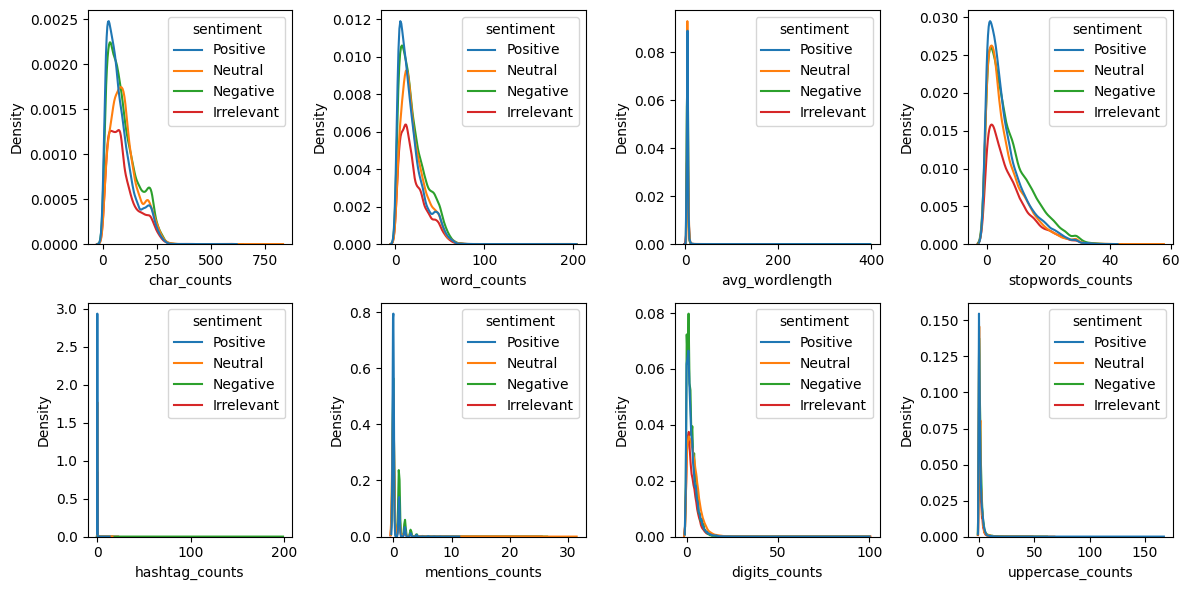

In [17]:
df.head()
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
num_cols=df.select_dtypes(include='number').columns

for index, col in enumerate(num_cols):
  plt.subplot(2,4,index+1)
  sns.kdeplot(data=df,x=col,hue="sentiment",fill=False)

plt.tight_layout()
plt.show()


<Axes: ylabel='count'>

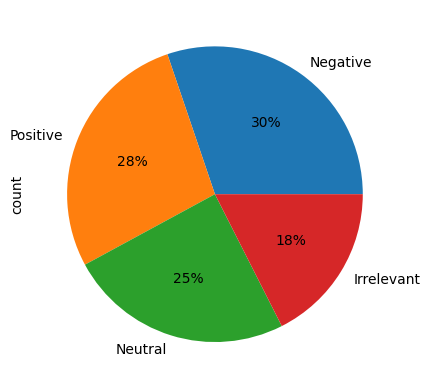

In [18]:
df['sentiment'].value_counts().plot(kind='pie',autopct="%1.0f%%")

In [19]:
#pip install wordcloud

from wordcloud import WordCloud,STOPWORDS
stopwords=set(STOPWORDS)

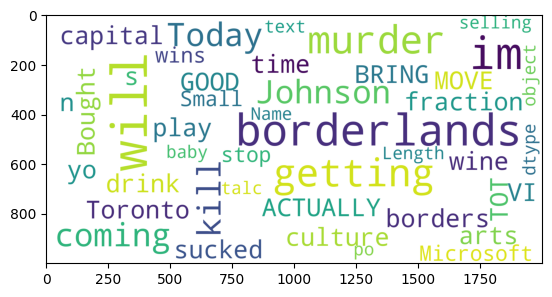

In [20]:
wordcloud=WordCloud(background_color='white',stopwords=stopwords,max_words=300,max_font_size=40,scale=5).generate(str(df['text']))
plt.imshow(wordcloud)



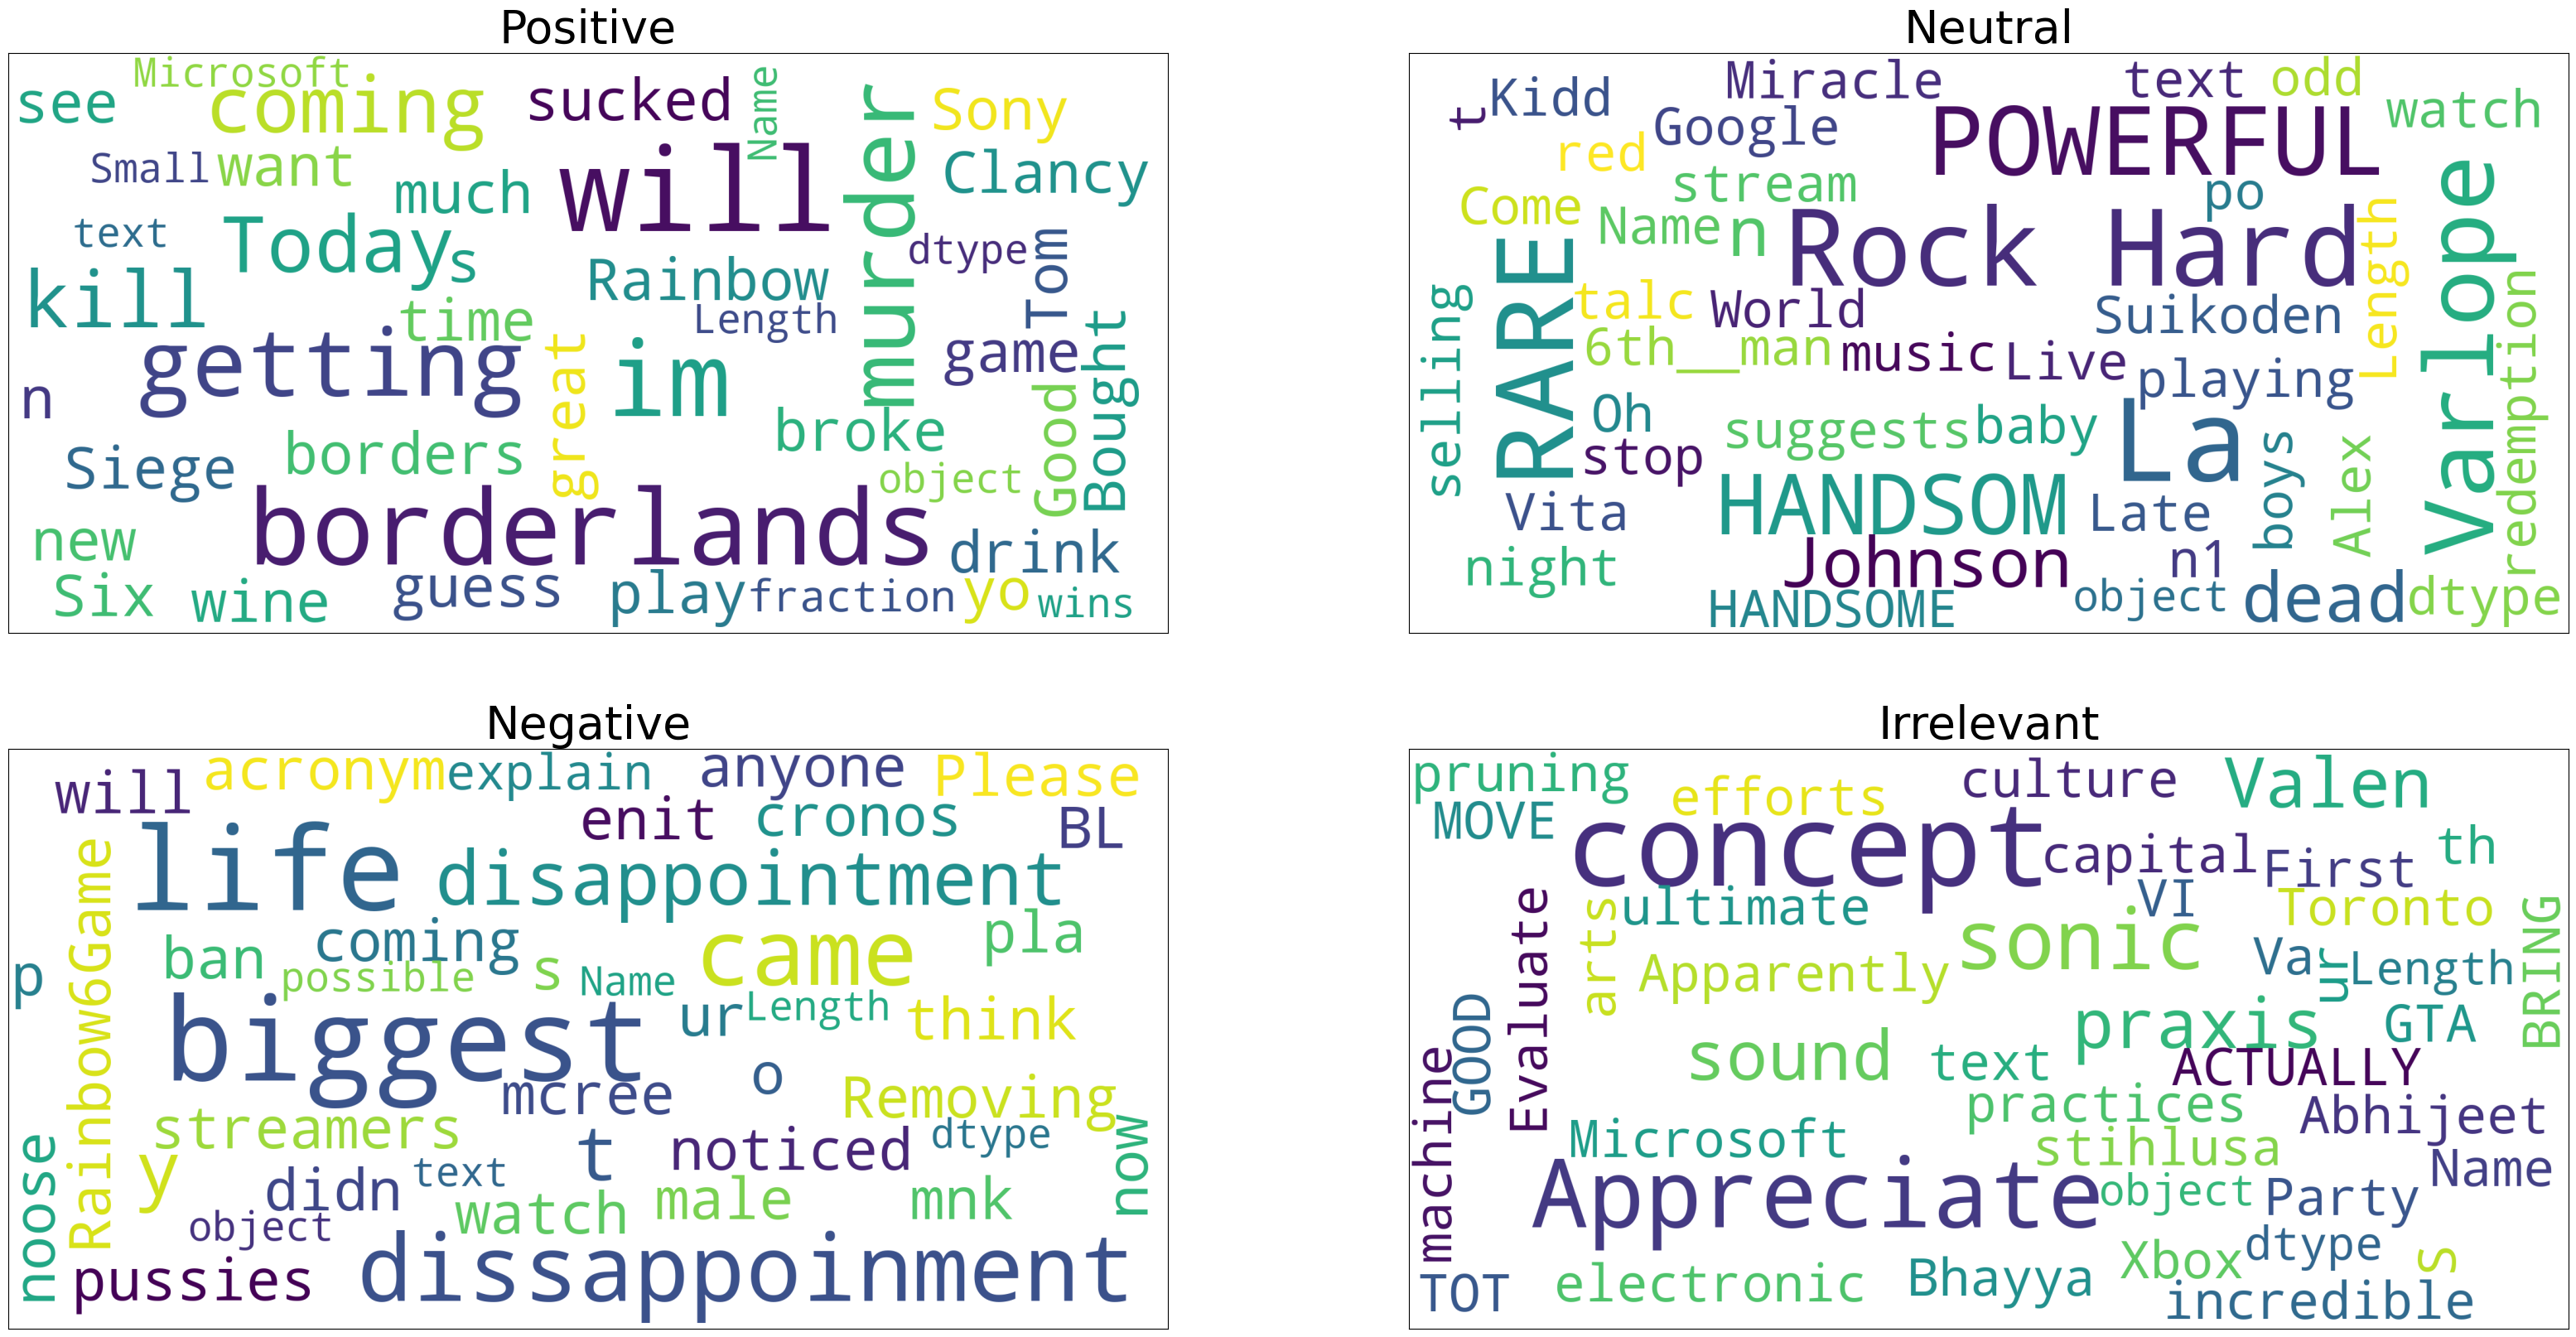

In [21]:
plt.figure(figsize=(40,20))

for index,sent in enumerate(df['sentiment'].unique()):
  plt.subplot(2,2,index+1)
  data=df[df['sentiment']==sent]['text']
  wordcloud=WordCloud(background_color='white',stopwords=stopwords,max_words=300,max_font_size=40,scale=5).generate(str(data))

  plt.imshow(wordcloud)
  plt.xticks([])
  plt.yticks([])
  plt.title(sent,fontsize=40)

In [22]:
df['text']=df['text'].apply(lambda x: x.lower())
df['text']=df['text'].apply(lambda x: ps.remove_html_tags(x))
df['text']=df['text'].apply(lambda x: ps.remove_rt(x))
df['text']=df['text'].apply(lambda x: ps.remove_special_chars(x))
df['text']=df['text'].apply(lambda x: ps.remove_urls(x))


In [23]:
from sklearn.model_selection import train_test_split

X = df['text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [24]:
X_train.shape,X_test.shape

((58306,), (14577,))

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline



In [41]:
clf=Pipeline([('tfid',TfidfVectorizer(stop_words=list(stopwords),max_features=5000)),
              ('rfc',RandomForestClassifier(n_estimators=50,n_jobs=-1))])

In [43]:
clf.fit(X_train,y_train)

Pipeline(steps=[('tfid',
                 TfidfVectorizer(max_features=5000,
                                 stop_words=['an', 'ours', 'shall', 'both',
                                             'has', 'before', 'for', 'is',
                                             "we've", "weren't", 'nor',
                                             'through', 'the', 'k', 'are',
                                             "doesn't", "won't", "they'll",
                                             'further', 'any', 'while', 'being',
                                             'have', 'ourselves', 'against',
                                             'which', 'themselves', 'also',
                                             'cannot', 'who', ...])),
                ('rfc', RandomForestClassifier(n_estimators=50, n_jobs=-1))])

In [44]:
from sklearn.metrics import classification_report

y_pred=clf.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

  Irrelevant       0.94      0.81      0.87      2561
    Negative       0.91      0.93      0.92      4481
     Neutral       0.89      0.88      0.89      3553
    Positive       0.85      0.92      0.88      3982

    accuracy                           0.89     14577
   macro avg       0.90      0.88      0.89     14577
weighted avg       0.89      0.89      0.89     14577



In [46]:
import pickle
pickle.dump(clf,open("twittwesentiment.pkl",'wb'))

In [47]:
clf.predict(['let me not upset you'])

array(['Negative'], dtype=object)

In [48]:
clf.predict([' I am really glad'])

array(['Positive'], dtype=object)

In [49]:
clf.predict(['hoe the hell is halloween'])

array(['Irrelevant'], dtype=object)